In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm

In [4]:
df = pd.read_csv("../out/gridsearch/results.csv")
df

,eta_infer,T_infer,lr,weight_decay,mean_val_accuracy,std_val_accuracy,mean_val_cross_entropy,elapsed_s
0,0.030857,34,0.000731,0.105972,0.825017,0.006333,1.854522e+00,64.570461
1,0.026347,67,0.001135,0.000836,0.745950,0.017990,1.815712e+00,88.566491
2,0.013257,130,0.000258,0.024571,0.717817,0.004788,1.863354e+00,135.009907
3,0.073936,15,0.000192,0.012145,0.666783,0.005450,1.868181e+00,50.527879
4,0.016893,105,0.004254,0.001600,0.663733,0.031132,1.854294e+00,116.473768
5,0.208329,96,0.000356,0.044042,0.649767,0.020440,1.868988e+00,109.928430
6,0.041762,29,0.002157,0.000101,0.255833,0.249226,1.212998e+11,60.672989
7,0.144239,116,0.001707,0.002817,0.223983,0.153933,2.320043e+00,125.234036
8,0.426761,81,0.000103,0.159443,0.109400,0.038544,2.530780e+00,98.820282
9,0.053468,80,0.005149,0.000318,0.106667,0.006139,2.627882e+11,98.438054


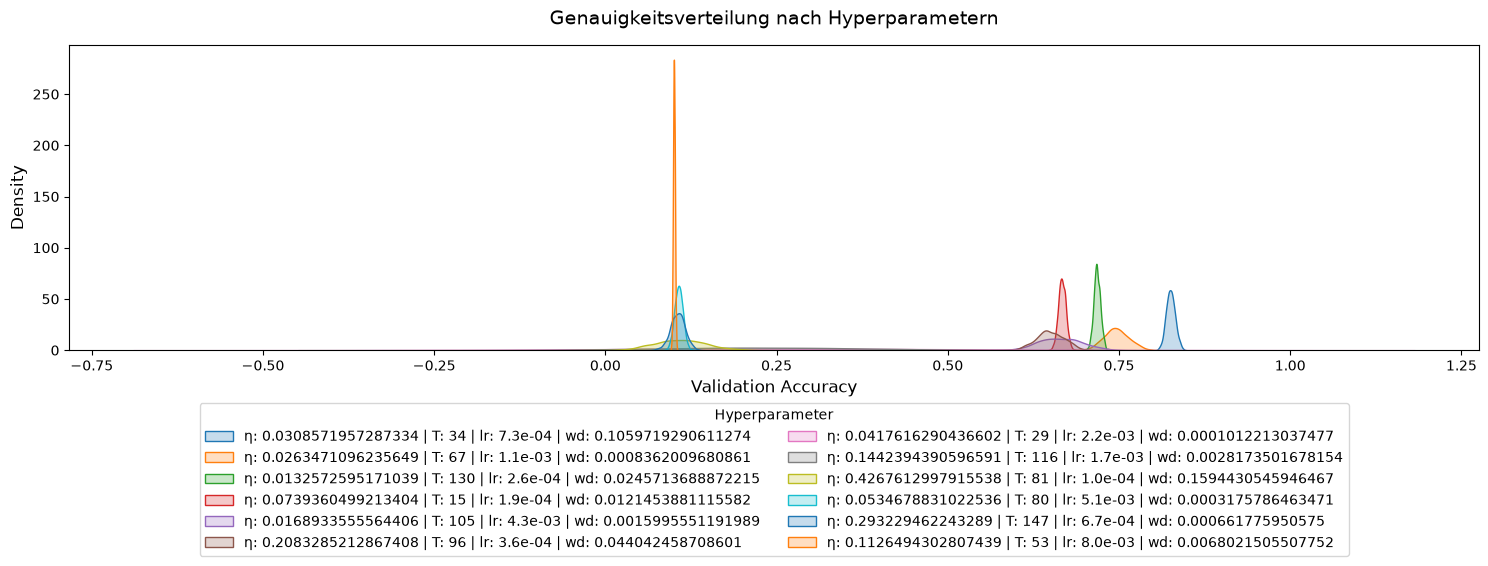

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

plt.figure(figsize=(15, 6))

for row in df.itertuples():
    # 1. Samples generieren
    samples = np.random.normal(
        loc=row.mean_val_accuracy, scale=row.std_val_accuracy, size=1000
    )

    # 2. Label AUSSCHLIESSLICH mit Hyperparametern befüllen
    # lr wird mit :.1e (z.B. 1e-3) formatiert, da Lernraten oft sehr klein sind
    label_text = (
        f"η: {row.eta_infer} | "
        f"T: {row.T_infer} | "
        f"lr: {row.lr:.1e} | "
        f"wd: {row.weight_decay}"
    )

    # 3. Plotten
    sns.kdeplot(samples, label=label_text, fill=True, common_norm=False)

# 4. Achsen und Titel
plt.title("Genauigkeitsverteilung nach Hyperparametern", fontsize=14, pad=15)
plt.xlabel("Validation Accuracy", fontsize=12)
plt.ylabel("Density", fontsize=12)

# 5. Legende horizontal unter dem Plot zentrieren
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    title="Hyperparameter",
)

plt.tight_layout()
plt.show()
